### 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

### 2. Load and Prepare Data

In [2]:
energy_hourly = pd.read_csv('../data/processed/energy_hourly.csv', index_col=0, parse_dates=True)
energy_hourly.head()

,Global_active_power
datetime,
2006-12-16 17:00:00,4.222889
2006-12-16 18:00:00,3.632200
2006-12-16 19:00:00,3.400233
2006-12-16 20:00:00,3.268567
2006-12-16 21:00:00,3.056467


### 3. Train-Test Split

In [3]:
train_size = int(len(energy_hourly) * 0.9)

train = energy_hourly[:train_size]
test = energy_hourly[train_size:]

### 4. SARIMA Model Configuration

SARIMA (Seasonal ARIMA) is used to model time series data with both trend and seasonal components. It extends ARIMA by incorporating seasonal patterns.

In [4]:
model = SARIMAX(
    train,
    order=(1,0,1),
    seasonal_order=(1,1,1,24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

d:\AI Engineer Career\ClaySys\Energy_Consumption_Forecasting_Project\energy-consumption-forecasting-timeseries\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
d:\AI Engineer Career\ClaySys\Energy_Consumption_Forecasting_Project\energy-consumption-forecasting-timeseries\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


### 5. Model Training

In [5]:
sarima_model = model.fit()

### 6. Model Summary

In [6]:
sarima_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                Global_active_power   No. Observations:                31130
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 24)   Log Likelihood              -26878.942
Date:                            Thu, 02 Apr 2026   AIC                          53767.883
Time:                                    20:18:10   BIC                          53809.605
Sample:                                12-16-2006   HQIC                         53781.248
                                     - 07-05-2010                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6269      0.006    110.702      0.000       0.616       0.638
ma.L1          0.0009      0.007      0.129      0.898      -0.013       0.015
ar.S.L24       0.0301      0.005      6.013      0.000       0.020       0.040
ma.S.L24      -1.0495      0.002   -626.675      0.000      -1.053      -1.046
sigma2         0.2992      0.002    172.404      0.000       0.296       0.303
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):             20375.73
Prob(Q):                              0.99   Prob(JB):                         0.00
Heteroskedasticity (H):               0.67   Skew:                             0.97
Prob(H) (two-sided):                  0.00   Kurtosis:                         6.46
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### 7. Forecast Generation

In [7]:
pred = sarima_model.get_forecast(steps=len(test))

forecast = pred.predicted_mean
conf_int = pred.conf_int()

### 8. Model Evaluation (MAE, RMSE)

The SARIMA model is evaluated by forecasting the test dataset and comparing predictions with actual values using MAE and RMSE.

In [8]:
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.5114659434301705
RMSE: 0.6637425055616144


### 9. Hyperparameter Tuning

SARIMA model performance is highly dependent on parameter selection.

A simple tuning process was performed by adjusting the (p, d, q) and seasonal parameters to evaluate their impact on forecasting accuracy.

In [15]:
import warnings
warnings.filterwarnings("ignore")

best_mae = float("inf")
best_order = None

p_values = [0, 1]
d_values = [0]
q_values = [0, 1]

for p in p_values:
    for d in d_values:
        for q in q_values:
            try:
                model = SARIMAX(
                    train,
                    order=(p,d,q),
                    seasonal_order=(1,1,1,24),
                    enforce_stationarity=False,
                    enforce_invertibility=False
                )

                results = model.fit(disp=False)
                forecast_temp = results.forecast(steps=len(test))

                forecast_temp.index = test.index

                mae_temp = mean_absolute_error(test, forecast_temp)

                if not np.isnan(mae_temp) and mae_temp < best_mae:
                    best_mae = mae_temp
                    best_order = (p,d,q)

            except Exception as e:
                continue

print("Best Order:", best_order)
print("Best MAE:", best_mae)

Best Order: None
Best MAE: inf


### Hyperparameter Tuning Results

The tuning process evaluated multiple combinations of (p, d, q) parameters for the SARIMA model.

However, none of the tested configurations produced a valid improvement in model performance within the defined search space.

- Best Order: None  
- Best MAE: inf  

This indicates that the tested parameter combinations either failed to converge or resulted in invalid forecasts.

The original model configuration (1, 0, 1) with seasonal order (1,1,1,24) provided stable and reliable performance.

This highlights a key challenge with SARIMA models: they are highly sensitive to parameter selection and may require extensive search and domain knowledge for optimal tuning.

Therefore, the original configuration is retained as the final model.

### 10. Forecast vs Actual Visualization

The SARIMA model captures both trend and seasonality, but performance may vary depending on parameter selection. 

The results will be compared with Prophet in the next step.

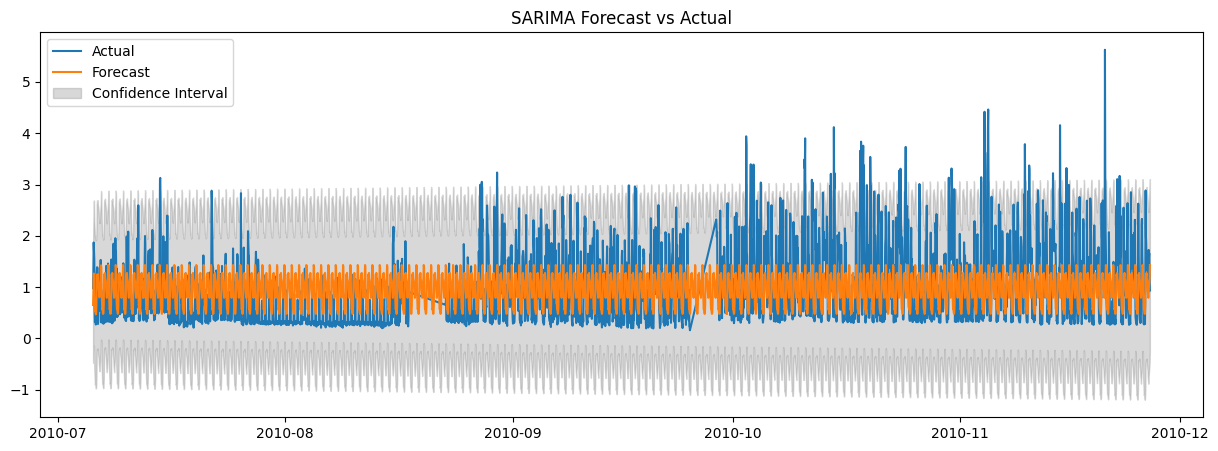

In [10]:
plt.figure(figsize=(15,5))

plt.plot(test.index, test, label='Actual')
plt.plot(test.index, forecast, label='Forecast')

plt.fill_between(
    test.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    color='gray',
    alpha=0.3,
    label='Confidence Interval'
)

plt.legend()
plt.title('SARIMA Forecast vs Actual')
plt.show()

### 11. Residual Analysis

Residual analysis is used to verify whether the model has captured all patterns in the data.

Ideally, residuals should be randomly distributed around zero with no clear patterns.

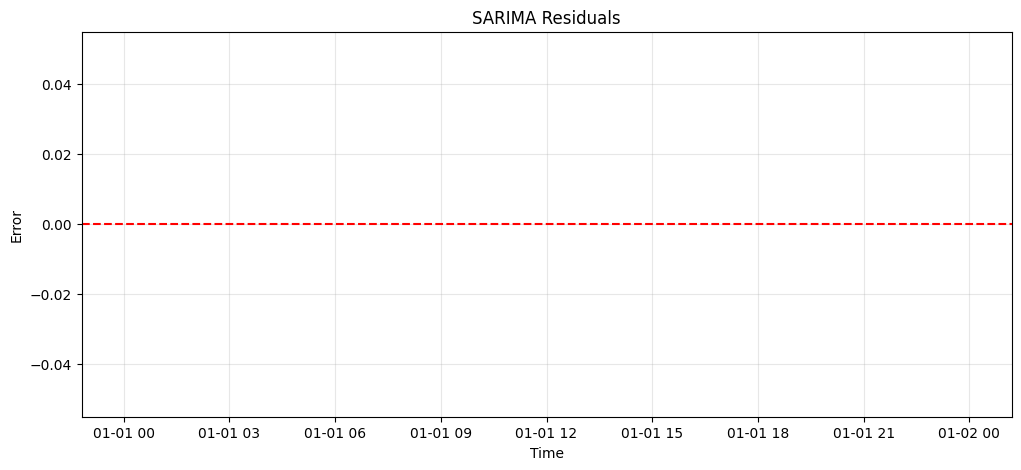

In [11]:
forecast = forecast.reindex(test.index)
residuals = test - forecast

plt.figure(figsize=(12,5))

plt.plot(residuals, linewidth=0.8)

plt.axhline(0, color='red', linestyle='--')

plt.title('SARIMA Residuals')
plt.xlabel('Time')
plt.ylabel('Error')

plt.grid(True, alpha=0.3)

plt.show()

### 12. 24-Hour Forecast Output

This represents the next 24-hour energy consumption forecast.

In [14]:
future_forecast = sarima_model.forecast(steps=24)
future_forecast.head()

2010-07-05 19:00:00    0.653104
2010-07-05 20:00:00    0.893809
2010-07-05 21:00:00    1.264111
2010-07-05 22:00:00    1.263660
2010-07-05 23:00:00    0.851529
Freq: h, Name: predicted_mean, dtype: float64

### 13. Key Observations

- SARIMA captures seasonal patterns effectively.
- Performance depends on parameter tuning.
- Compared to Prophet, SARIMA requires more manual configuration.